Model RLC circuit from Hollman's paper in EMT domain

In [57]:
from villas.dataprocessing.readtools import *
from villas.dataprocessing.timeseries import *
from villas.dataprocessing.timeseries import TimeSeries as ts
import matplotlib.pyplot as plt
import numpy as np
import dpsimpy
import re

#%matplotlib widget

epsilon = 1e-12

Define the model by creating components.

In [58]:
# Nodes
gnd = dpsimpy.dp.SimNode.gnd
n0 = dpsimpy.dp.SimNode("n0")
n1 = dpsimpy.dp.SimNode("n1")
n2 = dpsimpy.dp.SimNode("n2")

# Circuit elements
v_dc = dpsimpy.dp.ph1.VoltageSource("v_dc")
v_dc.set_parameters(V_ref=complex(8.5, 0))

r = dpsimpy.dp.ph1.Resistor("r")
r.R = 100

l = dpsimpy.dp.ph1.Inductor("l")
l.L = 5

c = dpsimpy.dp.ph1.Capacitor("c")
c.C = 250e-6

# Connections
v_dc.connect([gnd, n0])
r.connect([n0, n1])
l.connect([n1, n2])
c.connect([n2, gnd])

We now create a simulation object

In [59]:
sys = dpsimpy.SystemTopology(50, [ n0, n1, n2 ], [ v_dc, r, l, c ])
#I believe the first argument should be the frequency of the system but I am not sure

In [60]:
#help(dpsimpy.SystemTopology)
#help(dpsimpy.Simulation)

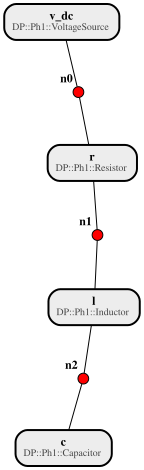

In [61]:
sys

In [62]:
sim = dpsimpy.Simulation("DP_Vdc_RLC", loglevel=dpsimpy.LogLevel.debug)
sim.set_domain(dpsimpy.Domain.DP)
sim.set_system(sys)
sim.set_time_step(0.006667)
sim.set_final_time(10)

log = dpsimpy.Logger("DP_Vdc_RLC")
for i in range(0, len(sys.nodes)):
    log.log_attribute("v" + str(i), "v", sys.nodes[i])

sim.add_logger(log)

In [63]:
sim.run()

[14:45:48.910210 DP_Vdc_RLC info] Initialize simulation: DP_Vdc_RLC
[14:45:48.917569 MnaSolverFactory info] creating KLUAdapter solver implementation
[14:45:48.940813 DP_Vdc_RLC info] Scheduling tasks.
[14:45:48.947037 DP_Vdc_RLC info] Scheduling done.
[14:45:48.947044 DP_Vdc_RLC info] Opening interfaces.
[14:45:48.947046 DP_Vdc_RLC info] Start synchronization with remotes on interfaces
[14:45:48.947046 DP_Vdc_RLC info] Synchronized simulation start with remotes
[14:45:48.947048 DP_Vdc_RLC info] Start simulation: DP_Vdc_RLC
[14:45:48.947050 DP_Vdc_RLC info] Time step: 6.667000e-03
[14:45:48.947052 DP_Vdc_RLC info] Final time: 1.000000e+01
[14:45:48.967050 DP_Vdc_RLC info] Simulation calculation time: 0.019963
[14:45:49.006699 DP_Vdc_RLC info] Simulation finished.


Plot the results

column number: 3
results length: 1500
real column names: []
complex column names: ['v0', 'v1', 'v2']


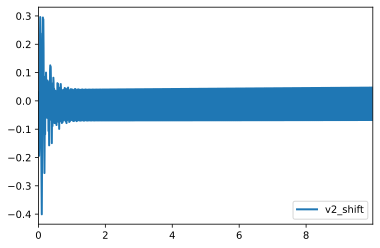

In [64]:
%matplotlib inline
%config InlineBackend.figure_format = 'svg'
%config InlineBackend.rc = {'font.size': 10, 'figure.figsize': (6.0, 4.0), 'figure.facecolor': 'white', 'savefig.dpi': 72, 'figure.subplot.bottom': 0.125, 'figure.edgecolor': 'white'}

import matplotlib.pyplot as plt
import villas.dataprocessing.plottools as pt
import villas.dataprocessing.readtools as rt
import villas.dataprocessing.timeseries as ts

results     = rt.read_timeseries_dpsim('logs/DP_Vdc_RLC.csv')
results_dp = [ results[series].frequency_shift(freq=50) for series in results ]

#for series in results_emt:
    #pt.plot_timeseries('Results EMT', series)
pt.plot_timeseries('Results DP', results_dp[2])
plt.show()